In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Author: Utkarsh Upadhyay
# Task 4: Customer Data Analysis

In [9]:
# Load the customer dataset
print("Loading Customer Data...")
df = pd.read_csv('customer_data.csv')

Loading Customer Data...


In [10]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual Income', 'Spending Score']

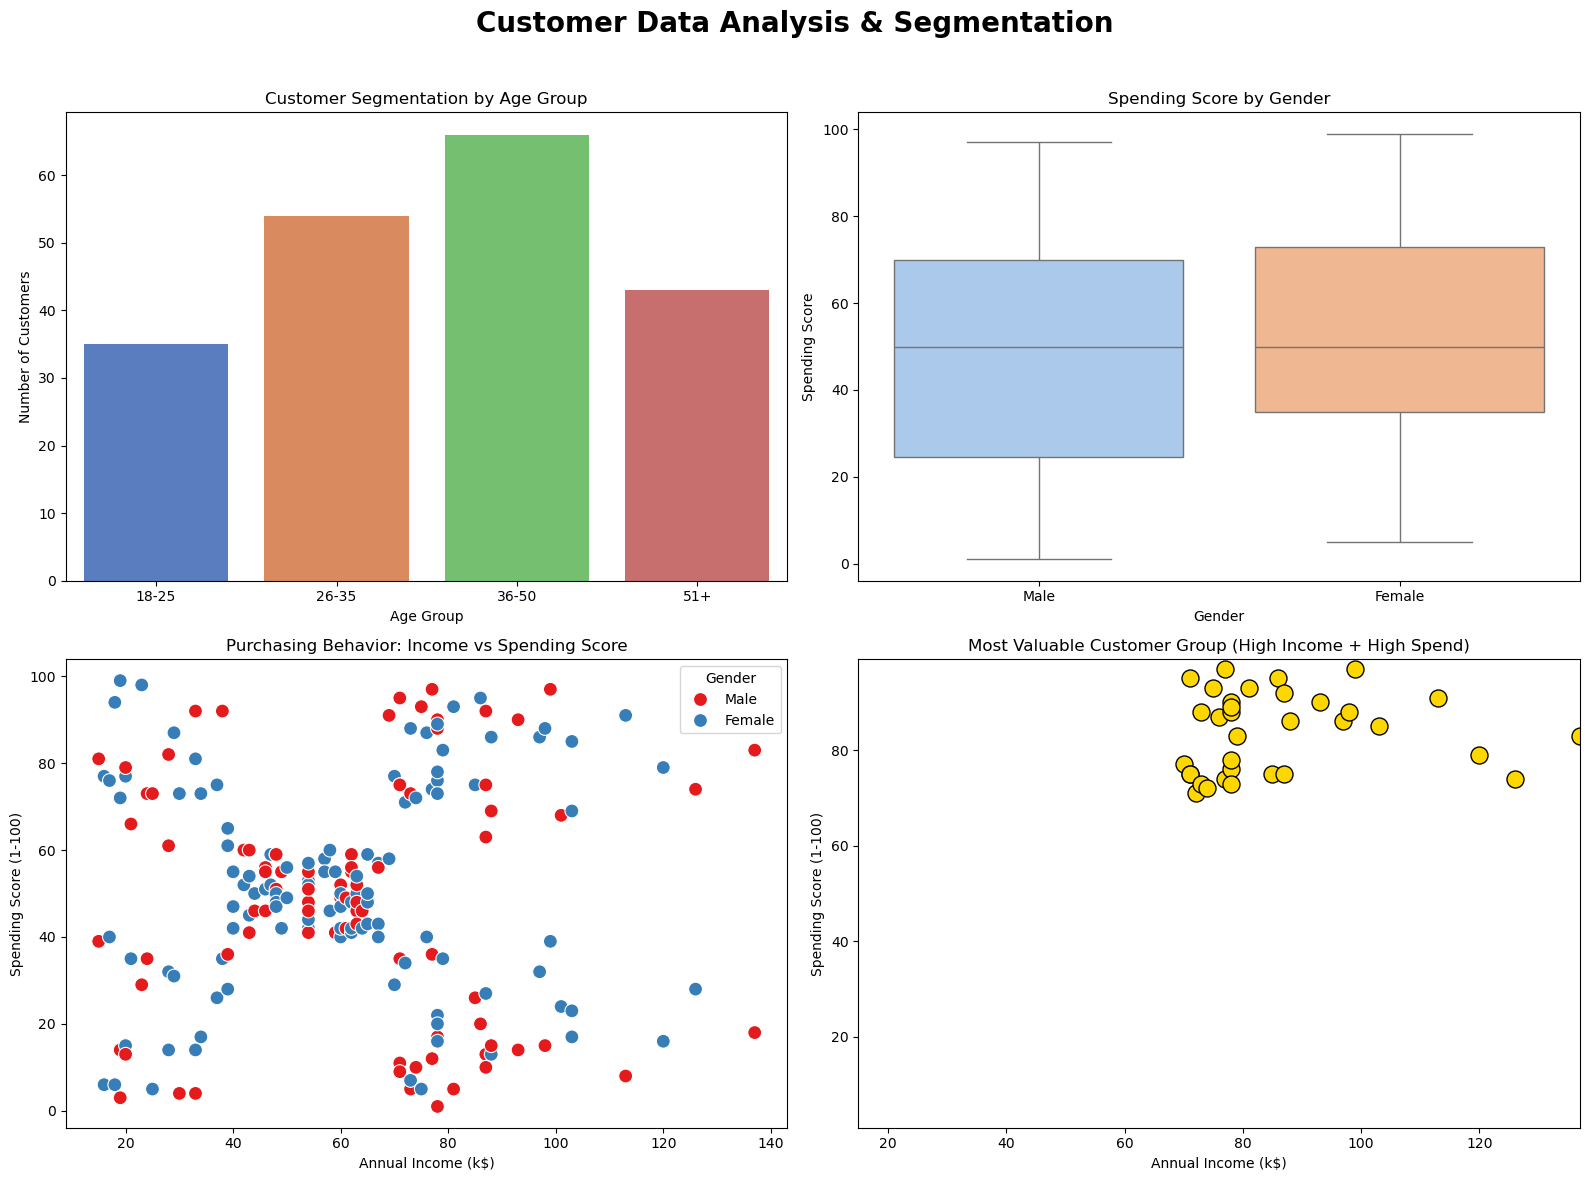

In [11]:
# --- 1. Segment customers based on age ---
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# --- 2. Analyze purchasing behavior & Create visual reports ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Data Analysis & Segmentation', fontsize=20, fontweight='bold')

# Plot A: Age Distribution
sns.countplot(x='Age Group', data=df, palette='muted', ax=axes[0, 0], hue='Age Group', legend=False)
axes[0, 0].set_title('Customer Segmentation by Age Group')
axes[0, 0].set_ylabel('Number of Customers')

# Plot B: Gender vs Spending Score
sns.boxplot(x='Gender', y='Spending Score', data=df, palette='pastel', ax=axes[0, 1], hue='Gender', legend=False)
axes[0, 1].set_title('Spending Score by Gender')

# Plot C: Annual Income vs Spending Score (Buying Patterns)
sns.scatterplot(x='Annual Income', y='Spending Score', hue='Gender', data=df, palette='Set1', s=100, ax=axes[1, 0])
axes[1, 0].set_title('Purchasing Behavior: Income vs Spending Score')
axes[1, 0].set_xlabel('Annual Income (k$)')
axes[1, 0].set_ylabel('Spending Score (1-100)')

# Plot D: Identifying Valuable Customers (High Income & High Spending)
valuable_customers = df[(df['Annual Income'] >= 70) & (df['Spending Score'] >= 70)]
sns.scatterplot(x='Annual Income', y='Spending Score', data=valuable_customers, color='gold', s=150, edgecolor='black', ax=axes[1, 1])
axes[1, 1].set_title('Most Valuable Customer Group (High Income + High Spend)')
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score (1-100)')
axes[1, 1].set_xlim(df['Annual Income'].min(), df['Annual Income'].max())
axes[1, 1].set_ylim(df['Spending Score'].min(), df['Spending Score'].max())

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [12]:
# --- 3. Identify the most valuable customer groups ---
print(f"\nIdentified {len(valuable_customers)} highly valuable customers (High Income, High Spending Score).")


Identified 34 highly valuable customers (High Income, High Spending Score).
